# Dialect/language-ID classifier -- classifier head on frozen embeddings

Supervised alternative to `scripts/word_cluster/`'s unsupervised
K-Means-tally baseline, built to fix its confirmed weak point: msa vs
darija separation (0.582 cluster purity, barely above 0.500 chance --
see `../plan.md`'s "Word-cluster classifier" section). Same overall
system shape as that baseline and as `label_dataset.py`, kept
deliberately consistent so results are comparable apples-to-apples:

- **`code_switch`/`other` are still decided by the deterministic script
  regex alone** (`script_of()`) -- never learned, never passed through
  the network. Only `{msa, darija, arabize, french, english}` rows are
  used for training/evaluation here, exactly the same subset
  `word_cluster/classify.py` reports "cluster-scored accuracy" on.
- **Two classifier heads sharing one trunk**, script-gated exactly like
  `label_dataset.py`'s two prompt templates and `word_cluster`'s two
  cluster groups: an **arabic head** (`msa`/`darija`, 2-way) and a
  **latin head** (`arabize`/`french`/`english`, 3-way). A row's script
  (`arabic` or `latin`) picks which head scores it, both at train and
  eval time -- the model can never even structurally output a
  script-impossible class, same guarantee the rest of this project's
  pipeline already relies on.
- **Architecture**: adapted directly from `NArabizi_sent/notebooks/
  02_train_classifier.ipynb` (frozen `CBOWAttention` embedder ->
  per-BPE-token contextualization -> word-level pooling -> `[CLS]` token
  (mean-pool-initialized) + learned positional embeddings -> a small
  trainable self-attention transformer stack -> gated-ReLU head). Same
  block-for-block reuse, just with two heads on the shared trunk instead
  of one, and mini-batch `DataLoader` training instead of full-batch
  (this dataset is ~15x NArabizi's, full-batch isn't practical here).

Run this notebook's kernel from the GPU venv (`ai-gpu`) -- the base
env's `torch` is CPU-only.


In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

ROOT = Path.cwd().resolve().parents[1]  # project root, when running from Dialect_Identification/notebooks/
DATA_DIR = ROOT / "Dialect_Identification" / "data"
MODELS_DIR = ROOT / "Dialect_Identification" / "models"
WORD2VEC_ATTENTION_DIR = ROOT / "Embeddings" / "word2vec_attention"

sys.path.insert(0, str(WORD2VEC_ATTENTION_DIR / "scripts"))
sys.path.insert(0, str(ROOT / "Tokenization"))
from model import CBOWAttention, masked_mean_pool  # noqa: E402
from tokenizer_utils import load_tokenizer  # noqa: E402

SEED = 0
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## 1. Script-gating helpers (same regex convention as `label_dataset.py` / `word_cluster/common.py`)

In [2]:
_MENTION_WITH_FRAGMENT_RE = __import__("re").compile(r"\[MENTION\](\s*-[^\s]{1,10})?")
_URL_RE = __import__("re").compile(r"\[URL\]")
_INLINE_WHITESPACE_RE = __import__("re").compile(r"[ \t]+")
_ARABIC_RE = __import__("re").compile(r"[\u0600-\u06ff\u0750-\u077f\u08a0-\u08ff\ufb50-\ufdff\ufe70-\ufeff]")
_LATIN_RE = __import__("re").compile(r"[a-zA-Z\u00c0-\u024f]")

ARABIC_CLASSES = ["msa", "darija"]
LATIN_CLASSES = ["arabize", "french", "english"]


def clean_for_classification(text: str) -> str:
    text = _MENTION_WITH_FRAGMENT_RE.sub("", text)
    text = _URL_RE.sub("", text)
    return _INLINE_WHITESPACE_RE.sub(" ", text).strip()


def script_of(text: str) -> str:
    has_ar = bool(_ARABIC_RE.search(text))
    has_lat = bool(_LATIN_RE.search(text))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"


## 2. Load the tokenizer + frozen embedding checkpoint

Same loading pattern as `word_cluster/common.py`'s `load_embedder()` and
the `word2vec_attention/word2vec_eval.ipynb` notebook -- picks the
highest-step `checkpoint_step*.pt` automatically.

In [3]:
meta = json.loads((WORD2VEC_ATTENTION_DIR / "data" / "meta.json").read_text(encoding="utf-8"))
tok = load_tokenizer(meta["tokenizer"]["key"], meta["tokenizer"]["vocab_size"])
vocab_size = meta["tokenizer"]["vocab_size_actual"]
PAD_ID = 0

checkpoints = sorted(
    (WORD2VEC_ATTENTION_DIR / "models").glob("checkpoint_step*.pt"),
    key=lambda p: int(p.stem.split("step")[-1]),
)
CHECKPOINT = checkpoints[-1]
ckpt = torch.load(CHECKPOINT, map_location=device)
ckpt_args = ckpt["args"]

embedder = CBOWAttention(
    vocab_size=vocab_size,
    embed_dim=ckpt_args["embed_dim"],
    num_heads=ckpt_args["num_heads"],
    ff_dim=ckpt_args["ff_dim"],
).to(device)
embedder.load_state_dict(ckpt["model_state_dict"])
embedder.eval()

EMBED_DIM = ckpt_args["embed_dim"]
print(f"Loaded checkpoint step={ckpt['step']:,} ({CHECKPOINT.name}), embed_dim={EMBED_DIM}, vocab={vocab_size:,}")


Loaded checkpoint step=675,000 (checkpoint_step675000.pt), embed_dim=128, vocab=20,000


## 3. Contextual embedding + word-pooling helpers

Identical to `NArabizi_sent`'s -- reapplies `embedder`'s own trained
self-attention/FFN block but returns the per-token sequence (no final
pooling), then averages BPE pieces back into one vector per word.

In [4]:
def contextualize(embedder: CBOWAttention, token_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    """token_ids: (batch, seq) ids. attention_mask: (batch, seq) bool, True = real token.
    Returns (batch, seq, embed_dim) contextualized per-token embeddings.
    """
    x = embedder.input_embeddings(token_ids)
    attn_out, _ = embedder.self_attn(x, x, x, key_padding_mask=~attention_mask, need_weights=False)
    x = embedder.norm1(x + attn_out)
    ffn_out = embedder.ffn(x)
    x = embedder.norm2(x + ffn_out)
    return x


def pool_tokens_to_words(
    token_embeds: torch.Tensor, attention_mask: torch.Tensor, word_ids: torch.Tensor
) -> tuple[torch.Tensor, torch.Tensor]:
    """token_embeds: (batch, seq, embed_dim). attention_mask: (batch, seq) bool.
    word_ids: (batch, seq) long, dummy 0 at padded positions.
    Returns (word_embeds: (batch, max_words, embed_dim), word_mask: (batch, max_words) bool).
    """
    batch, seq, embed_dim = token_embeds.shape
    max_words = int(word_ids.max().item()) + 1

    mask_f = attention_mask.unsqueeze(-1).to(token_embeds.dtype)
    masked_embeds = token_embeds * mask_f

    sums = torch.zeros(batch, max_words, embed_dim, device=token_embeds.device, dtype=token_embeds.dtype)
    sums.scatter_add_(1, word_ids.unsqueeze(-1).expand(-1, -1, embed_dim), masked_embeds)

    counts = torch.zeros(batch, max_words, device=token_embeds.device, dtype=token_embeds.dtype)
    counts.scatter_add_(1, word_ids, attention_mask.to(token_embeds.dtype))

    word_embeds = sums / counts.clamp(min=1.0).unsqueeze(-1)
    word_mask = counts > 0
    return word_embeds, word_mask


## 4. Trainable transformer block (fast self-attention + gated-ReLU FFN)

Same block shape as `NArabizi_sent`'s, stacked `NUM_LAYERS` times.

In [5]:
class FastSelfAttentionBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.dropout_p = dropout

        self.qkv_proj = nn.Linear(embed_dim, 3 * embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.norm_attn = nn.LayerNorm(embed_dim)

        self.gate_proj = nn.Linear(embed_dim, 2 * ff_dim)
        self.down_proj = nn.Linear(ff_dim, embed_dim)
        self.norm_ffn = nn.LayerNorm(embed_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        b, t, d = x.shape

        qkv = self.qkv_proj(x).view(b, t, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn_mask = attention_mask[:, None, None, :]
        attn_out = F.scaled_dot_product_attention(
            q, k, v, attn_mask=attn_mask, dropout_p=self.dropout_p if self.training else 0.0
        )
        attn_out = attn_out.transpose(1, 2).reshape(b, t, d)
        attn_out = self.out_proj(attn_out)
        x = self.norm_attn(x + self.dropout(attn_out))

        gated = self.gate_proj(x)
        a, gate = gated.chunk(2, dim=-1)
        ffn_out = self.down_proj(F.relu(a) * gate)
        x = self.norm_ffn(x + self.dropout(ffn_out))

        return x


class TransformerEncoderStack(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, ff_dim: int, num_layers: int, dropout: float = 0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [FastSelfAttentionBlock(embed_dim, num_heads, ff_dim, dropout=dropout) for _ in range(num_layers)]
        )

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x, attention_mask)
        return x


class GatedReLUHead(nn.Module):
    def __init__(self, embed_dim: int, hidden_dim: int, num_classes: int, dropout: float = 0.1):
        super().__init__()
        self.gate_proj = nn.Linear(embed_dim, 2 * hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(hidden_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        a, gate = self.gate_proj(x).chunk(2, dim=-1)
        h = self.dropout(F.relu(a) * gate)
        return self.out_proj(h)


## 5. Full model: shared trunk, two script-gated heads

`forward()` always computes both heads' logits from the same `[CLS]`
representation -- the caller picks which head's output to use per row
(`arabic_logits` / `latin_logits`), keyed by that row's own script group.
Ties everything together: contextualize -> pool to words -> prepend
`[CLS]` (mean-pool-initialized) -> add positional embeddings ->
`NUM_LAYERS`-deep transformer stack -> `[CLS]`'s own output vector ->
both heads.

In [6]:
class DialectClassifier(nn.Module):
    def __init__(self, embedder: CBOWAttention, embed_dim: int, num_heads: int, ff_dim: int,
                 freeze_embedder: bool = True, dropout: float = 0.1,
                 head_hidden_dim: int = 128, max_positions: int = 110, num_layers: int = 2):
        super().__init__()
        self.embedder = embedder
        self.freeze_embedder = freeze_embedder
        if freeze_embedder:
            for p in self.embedder.parameters():
                p.requires_grad = False

        self.pos_embedding = nn.Embedding(max_positions, embed_dim)
        self.encoder = TransformerEncoderStack(embed_dim, num_heads, ff_dim, num_layers=num_layers, dropout=dropout)
        self.arabic_head = GatedReLUHead(embed_dim, head_hidden_dim, len(ARABIC_CLASSES), dropout=dropout)
        self.latin_head = GatedReLUHead(embed_dim, head_hidden_dim, len(LATIN_CLASSES), dropout=dropout)

    def encode(self, token_ids: torch.Tensor, attention_mask: torch.Tensor, word_ids: torch.Tensor) -> torch.Tensor:
        """Shared trunk -> (batch, embed_dim) [CLS] representation."""
        if self.freeze_embedder:
            with torch.no_grad():
                token_embeds = contextualize(self.embedder, token_ids, attention_mask)
        else:
            token_embeds = contextualize(self.embedder, token_ids, attention_mask)

        word_embeds, word_mask = pool_tokens_to_words(token_embeds, attention_mask, word_ids)
        batch_size = word_embeds.size(0)

        cls_init = masked_mean_pool(word_embeds, word_mask).unsqueeze(1)
        x = torch.cat([cls_init, word_embeds], dim=1)
        cls_mask = torch.ones(batch_size, 1, dtype=torch.bool, device=word_mask.device)
        full_mask = torch.cat([cls_mask, word_mask], dim=1)

        seq_len = x.size(1)
        assert seq_len <= self.pos_embedding.num_embeddings, (
            f"sequence (CLS + {seq_len - 1} words) exceeds max_positions={self.pos_embedding.num_embeddings}"
        )
        positions = torch.arange(seq_len, device=x.device)
        x = x + self.pos_embedding(positions).unsqueeze(0)

        x = self.encoder(x, full_mask)
        return x[:, 0, :]  # [CLS]'s own output vector

    def forward(self, token_ids: torch.Tensor, attention_mask: torch.Tensor, word_ids: torch.Tensor):
        cls_out = self.encode(token_ids, attention_mask, word_ids)
        return self.arabic_head(cls_out), self.latin_head(cls_out)


## 6. Data loading

`code_switch`/`other` rows are dropped entirely here (not this network's
job -- the deterministic script rule already handles them with 100%
accuracy by construction, same as `word_cluster/classify.py`). A row is
truncated to its first `MAX_WORDS` words at data-loading time -- language
ID doesn't need a whole document, and the rare very-long djelfa post
would otherwise dominate a batch's padding cost (same rationale as
`label_dataset.py`'s `MAX_PROMPT_CHARS`).

In [7]:
MAX_WORDS = 100  # -> max_positions = MAX_WORDS + 1 (CLS) = 101, comfortably under the 110 set above


def encode_words(text: str) -> tuple[list[int], list[int]]:
    """Returns (token_ids, word_ids); word_ids[i] is the (0-based) word
    index token_ids[i] belongs to. Truncated to the first MAX_WORDS words.
    """
    token_ids: list[int] = []
    word_ids: list[int] = []
    next_word_idx = 0
    for word in text.split()[:MAX_WORDS]:
        piece_ids = tok.encode(word)
        if not piece_ids:
            continue
        token_ids.extend(piece_ids)
        word_ids.extend([next_word_idx] * len(piece_ids))
        next_word_idx += 1
    return token_ids, word_ids


class DialectDataset(Dataset):
    """group: 'arabic' ({msa, darija}) or 'latin' ({arabize, french, english}).
    Rows are script-gated the same way build_dataset/label_dataset/word_cluster
    already do -- script_of(clean_for_classification(text)).
    """
    def __init__(self, split: str, group: str):
        classes = ARABIC_CLASSES if group == "arabic" else LATIN_CLASSES
        label_to_id = {label: i for i, label in enumerate(classes)}
        self.rows = []
        with (DATA_DIR / f"{split}.jsonl").open("r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                r = json.loads(line)
                if r["label"] not in classes:
                    continue
                if script_of(clean_for_classification(r["text"])) != group:
                    continue  # label/script disagreement (shouldn't happen given label_dataset.py's own gating) -- skip defensively
                token_ids, word_ids = encode_words(r["text"])
                if not token_ids:
                    continue
                self.rows.append((token_ids, word_ids, label_to_id[r["label"]]))

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        return self.rows[idx]


def make_collate(device):
    def collate(batch):
        token_ids_list, word_ids_list, labels = zip(*batch)
        max_len = max(len(ids) for ids in token_ids_list)
        token_ids = torch.full((len(batch), max_len), PAD_ID, dtype=torch.long)
        attention_mask = torch.zeros((len(batch), max_len), dtype=torch.bool)
        word_ids = torch.zeros((len(batch), max_len), dtype=torch.long)
        for i, (ids, wids) in enumerate(zip(token_ids_list, word_ids_list)):
            n = len(ids)
            token_ids[i, :n] = torch.tensor(ids, dtype=torch.long)
            attention_mask[i, :n] = True
            word_ids[i, :n] = torch.tensor(wids, dtype=torch.long)
        return (
            token_ids.to(device),
            attention_mask.to(device),
            word_ids.to(device),
            torch.tensor(labels, dtype=torch.long).to(device),
        )
    return collate


collate = make_collate(device)

BATCH_SIZE = 128
arabic_train_ds = DialectDataset("train", "arabic")
latin_train_ds = DialectDataset("train", "latin")
arabic_test_ds = DialectDataset("test", "arabic")
latin_test_ds = DialectDataset("test", "latin")

arabic_train_loader = DataLoader(arabic_train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
latin_train_loader = DataLoader(latin_train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
arabic_test_loader = DataLoader(arabic_test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
latin_test_loader = DataLoader(latin_test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

print(f"arabic: train={len(arabic_train_ds):,} test={len(arabic_test_ds):,}")
print(f"latin:  train={len(latin_train_ds):,} test={len(latin_test_ds):,}")


arabic: train=6,660 test=1,665
latin:  train=4,563 test=1,142


## 7. Build the model + optimizer

In [8]:
FREEZE_EMBEDDER = True
NUM_EPOCHS = 12
LEARNING_RATE = 1e-3
DROPOUT = 0.2
NUM_LAYERS = 2

model = DialectClassifier(
    embedder=embedder,
    embed_dim=EMBED_DIM,
    num_heads=ckpt_args["num_heads"],
    ff_dim=ckpt_args["ff_dim"],
    freeze_embedder=FREEZE_EMBEDDER,
    dropout=DROPOUT,
    num_layers=NUM_LAYERS,
).to(device)

trainable_params = [p for p in model.parameters() if p.requires_grad]
n_trainable = sum(p.numel() for p in trainable_params)
n_total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {n_trainable:,} / {n_total:,}")

optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()


Trainable params: 609,413 / 5,927,685


## 8. Train

One epoch = one full pass over the **larger** of the two train sets
(arabic); the smaller (latin) loader is cycled to keep pace. Each step
draws one batch from each group, computes both heads' losses against
their own batch, sums them, and backprops through the shared trunk +
both heads together -- a standard joint multi-task training loop, not
two separate training runs.

In [9]:
import itertools


def run_epoch(arabic_loader, latin_loader, train: bool):
    model.train(train)
    stats = {
        "arabic": {"loss": 0.0, "n": 0, "correct": 0},
        "latin": {"loss": 0.0, "n": 0, "correct": 0},
    }
    n_steps = max(len(arabic_loader), len(latin_loader))
    arabic_iter = itertools.cycle(arabic_loader) if len(arabic_loader) < n_steps else iter(arabic_loader)
    latin_iter = itertools.cycle(latin_loader) if len(latin_loader) < n_steps else iter(latin_loader)

    for _ in range(n_steps):
        arabic_batch = next(arabic_iter)
        latin_batch = next(latin_iter)
        with torch.set_grad_enabled(train):
            a_token_ids, a_mask, a_word_ids, a_labels = arabic_batch
            l_token_ids, l_mask, l_word_ids, l_labels = latin_batch

            arabic_logits, _ = model(a_token_ids, a_mask, a_word_ids)
            _, latin_logits = model(l_token_ids, l_mask, l_word_ids)

            a_loss = criterion(arabic_logits, a_labels)
            l_loss = criterion(latin_logits, l_labels)
            loss = a_loss + l_loss

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        for group, logits, labels, group_loss in (
            ("arabic", arabic_logits, a_labels, a_loss), ("latin", latin_logits, l_labels, l_loss),
        ):
            stats[group]["loss"] += group_loss.item() * len(labels)
            stats[group]["n"] += len(labels)
            stats[group]["correct"] += (logits.argmax(dim=-1) == labels).sum().item()

    return {
        group: (s["loss"] / s["n"], s["correct"] / s["n"])
        for group, s in stats.items()
    }


train_history = []
for epoch in range(1, NUM_EPOCHS + 1):
    result = run_epoch(arabic_train_loader, latin_train_loader, train=True)
    train_history.append(result)
    a_loss, a_acc = result["arabic"]
    l_loss, l_acc = result["latin"]
    print(f"epoch {epoch:>3}  arabic: loss={a_loss:.4f} acc={a_acc:.3f}   latin: loss={l_loss:.4f} acc={l_acc:.3f}")


epoch   1  arabic: loss=0.6001 acc=0.675   latin: loss=0.7382 acc=0.675


epoch   2  arabic: loss=0.5560 acc=0.708   latin: loss=0.5237 acc=0.792


epoch   3  arabic: loss=0.4759 acc=0.766   latin: loss=0.4647 acc=0.822


epoch   4  arabic: loss=0.4382 acc=0.786   latin: loss=0.4403 acc=0.820


epoch   5  arabic: loss=0.4338 acc=0.791   latin: loss=0.4230 acc=0.833


...

epoch   8  arabic: loss=0.3915 acc=0.814   latin: loss=0.3931 acc=0.848


epoch   9  arabic: loss=0.3998 acc=0.809   latin: loss=0.3773 acc=0.853


epoch  10  arabic: loss=0.4330 acc=0.794   latin: loss=0.4117 acc=0.836


epoch  11  arabic: loss=0.3894 acc=0.815   latin: loss=0.3776 acc=0.851


epoch  12  arabic: loss=0.4008 acc=0.811   latin: loss=0.3658 acc=0.858


## 9. Loss curves

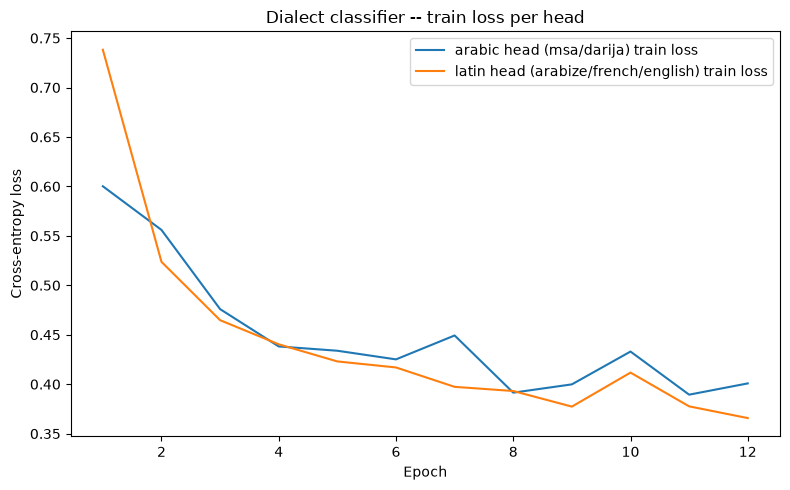

In [10]:
epochs = range(1, NUM_EPOCHS + 1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, [h["arabic"][0] for h in train_history], label="arabic head (msa/darija) train loss")
ax.plot(epochs, [h["latin"][0] for h in train_history], label="latin head (arabize/french/english) train loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Dialect classifier -- train loss per head")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Final test-set evaluation

Same shape as `word_cluster/classify.py`'s report -- per-class accuracy +
confusion matrix per head, plus a combined "cluster-scored accuracy"
number directly comparable to that baseline's 0.562.

In [11]:
def evaluate(loader, classes: list[str]):
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for token_ids, attention_mask, word_ids, labels in loader:
            arabic_logits, latin_logits = model(token_ids, attention_mask, word_ids)
            logits = arabic_logits if classes is ARABIC_CLASSES else latin_logits
            preds = logits.argmax(dim=-1)
            all_true.extend(labels.tolist())
            all_pred.extend(preds.tolist())
    return all_true, all_pred


arabic_true, arabic_pred = evaluate(arabic_test_loader, ARABIC_CLASSES)
latin_true, latin_pred = evaluate(latin_test_loader, LATIN_CLASSES)

n_correct = sum(t == p for t, p in zip(arabic_true, arabic_pred)) + sum(t == p for t, p in zip(latin_true, latin_pred))
n_total = len(arabic_true) + len(latin_true)
print(f"Cluster-scored accuracy (msa/darija/arabize/french/english, same definition as word_cluster/classify.py): "
      f"{n_correct / n_total:.4f} ({n_correct}/{n_total})")

print("\nPer-class accuracy:")
for classes, true, pred in ((ARABIC_CLASSES, arabic_true, arabic_pred), (LATIN_CLASSES, latin_true, latin_pred)):
    for ci, cname in enumerate(classes):
        idx = [i for i, t in enumerate(true) if t == ci]
        acc = sum(pred[i] == ci for i in idx) / len(idx) if idx else float("nan")
        print(f"  {cname:<12} {sum(pred[i] == ci for i in idx):>5}/{len(idx):<5} acc={acc:.3f}")


Cluster-scored accuracy (msa/darija/arabize/french/english, same definition as word_cluster/classify.py): 0.8368 (2349/2807)

Per-class accuracy:
  msa            422/542   acc=0.779
  darija         942/1123  acc=0.839
  arabize        584/621   acc=0.940
  french         341/415   acc=0.822
  english         60/106   acc=0.566


In [12]:
def print_confusion(classes: list[str], true: list[int], pred: list[int], title: str):
    n = len(classes)
    mat = [[0] * n for _ in range(n)]
    for t, p in zip(true, pred):
        mat[t][p] += 1
    print(f"\n{title} confusion matrix (rows=true, cols=predicted):")
    header = "true\\pred" + "".join(f"{c:>12}" for c in classes)
    print(header)
    for i, c in enumerate(classes):
        print(f"{c:<10}" + "".join(f"{mat[i][j]:>12}" for j in range(n)))


print_confusion(ARABIC_CLASSES, arabic_true, arabic_pred, "Arabic head (msa/darija)")
print_confusion(LATIN_CLASSES, latin_true, latin_pred, "Latin head (arabize/french/english)")



Arabic head (msa/darija) confusion matrix (rows=true, cols=predicted):
true\pred         msa      darija
msa                422         120
darija             181         942

Latin head (arabize/french/english) confusion matrix (rows=true, cols=predicted):
true\pred     arabize      french     english
arabize            584          24          13
french              61         341          13
english             37           9          60


## 11. Save the trained model

In [13]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
save_path = MODELS_DIR / "classifier_head.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "embed_dim": EMBED_DIM,
    "num_heads": ckpt_args["num_heads"],
    "ff_dim": ckpt_args["ff_dim"],
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "checkpoint_used": str(CHECKPOINT),
    "arabic_classes": ARABIC_CLASSES,
    "latin_classes": LATIN_CLASSES,
    "max_words": MAX_WORDS,
}, save_path)
print(f"Saved to {save_path}")


Saved to C:\Users\ASUS\Desktop\summer 2026\Darija\Dialect_Identification\models\classifier_head.pt
